In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from scipy.stats import shapiro, normaltest, pearsonr, wilcoxon, spearmanr, kruskal, f_oneway, chi2_contingency

In [2]:
df5 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_eff.csv", index_col = 0)

# Bivariate Analysis

## Literacy vs GDP Correlation

In [3]:
# Compute Correlation
df5[["adult_literacy_rate", "log_gdp"]].corr()

,adult_literacy_rate,log_gdp
adult_literacy_rate,1.000000,0.705943
log_gdp,0.705943,1.000000


In [4]:
df5[['youth_literacy_avg','log_gdp']].corr()

,youth_literacy_avg,log_gdp
youth_literacy_avg,1.000000,0.666983
log_gdp,0.666983,1.000000


In [5]:
df5[["literacy_index", "log_gdp"]].corr()

,literacy_index,log_gdp
literacy_index,1.000000,0.701667
log_gdp,0.701667,1.000000


In [6]:
df5[["education_development_index", "log_gdp"]].corr()

,education_development_index,log_gdp
education_development_index,1.000000,0.738361
log_gdp,0.738361,1.000000


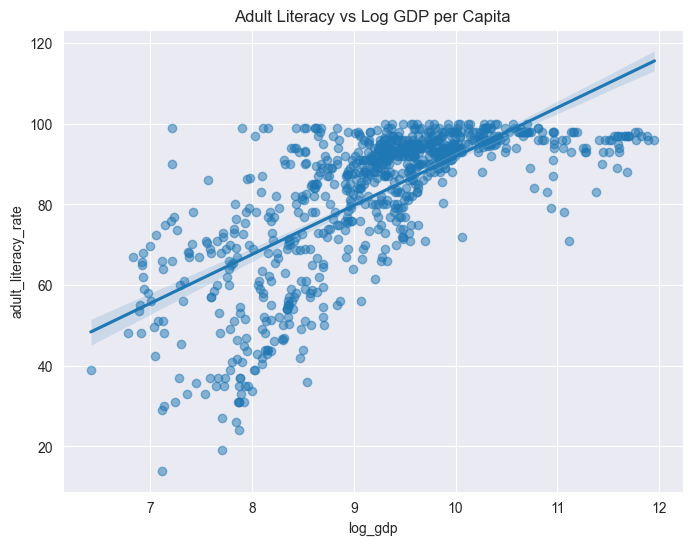

In [7]:
# Scatter Plot with Trend Line
plt.figure(figsize = (8, 6))
sns.regplot(x = "log_gdp", y = "adult_literacy_rate", data = df5, scatter_kws = {"alpha" : 0.5})
plt.title("Adult Literacy vs Log GDP per Capita")
plt.show()

### The relationship between log GDP per capita and adult literacy rate is strongly positive and approximately linear at lower and middle income levels. However, a clear ceiling effect emerges among high-income countries, where literacy rates plateau near universal levels. Additionally, substantial variation among low-income nations suggests that governance and policy efficiency significantly influence literacy outcomes beyond economic capacity alone.


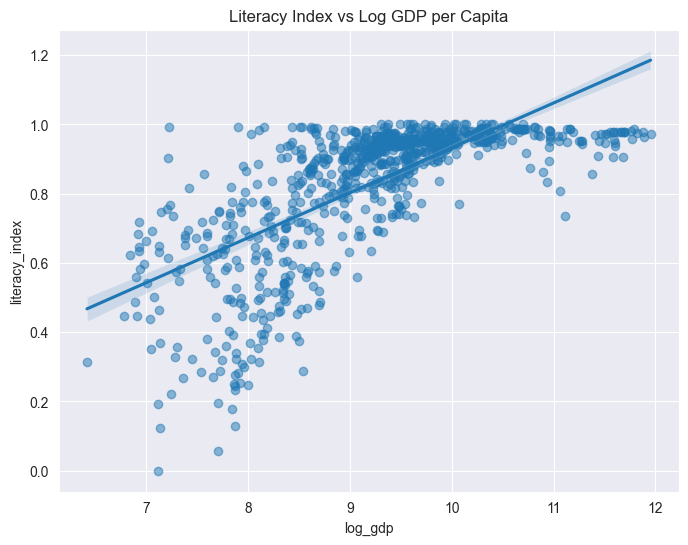

In [8]:
plt.figure(figsize = (8, 6))
sns.regplot(x = "log_gdp", y = "literacy_index", data = df5, scatter_kws = {"alpha" : 0.5})
plt.title("Literacy Index vs Log GDP per Capita")
plt.show()

### The literacy index exhibits a strong positive association with log GDP per capita, displaying a clear three-phase development pattern: high variability at low income levels, rapid gains during middle-income transitions, and saturation at high income levels. Compared to raw literacy rates, the composite literacy index demonstrates a more structured and stable economic relationship.

In [9]:
# Outlier Insights
df5[(df5["log_gdp_norm"] > 0.7) & (df5["adult_literacy_rate"] < 80)]

,country,code,year,adult_literacy_rate,youth_literacy_rate_M,youth_literacy_rate_F,continent,invalid_literacy_flag,adult_literacy_rate_outlier_flag,youth_literacy_rate_M_outlier_flag,...,regional_convergence_index,avg_schooling_years,adult_literacy_rate_norm,youth_literacy_avg_norm,avg_schooling_years_norm,literacy_index,education_development_index,log_gdp,log_gdp_norm,education_spend_efficiency
408,Kuwait,KWT,1995,78.0,94.0,90.0,Asia,False,False,False,...,13.128541,6.15,0.744186,0.90000,0.425125,0.806512,0.692096,11.068099,0.840045,-0.147949
677,Saudi Arabia,SAU,1992,71.0,94.0,81.0,Asia,False,False,False,...,NaN,9.34,0.662791,0.84375,0.690516,0.735174,0.721777,11.115189,0.848550,-0.126774
678,Saudi Arabia,SAU,2000,79.0,98.0,94.0,Asia,False,False,False,...,-5.538543,9.34,0.755814,0.95000,0.690516,0.833488,0.790597,10.932433,0.815540,-0.024943


These countries demonstrate economic capacity but underperform in education outcomes, suggesting governance or policy inefficiencies.

In [10]:
df5[(df5["log_gdp_norm"] < 0.4) & (df5["adult_literacy_rate"] > 90)]

,country,code,year,adult_literacy_rate,youth_literacy_rate_M,youth_literacy_rate_F,continent,invalid_literacy_flag,adult_literacy_rate_outlier_flag,youth_literacy_rate_M_outlier_flag,...,regional_convergence_index,avg_schooling_years,adult_literacy_rate_norm,youth_literacy_avg_norm,avg_schooling_years_norm,literacy_index,education_development_index,log_gdp,log_gdp_norm,education_spend_efficiency
17,Armenia,ARM,2000,99.00000,100.00000,100.00000,Asia,False,False,False,...,-5.538543,10.450,0.988372,1.000000,0.782862,0.993023,0.929975,8.431419,0.363794,0.566181
18,Armenia,ARM,2001,99.00000,100.00000,100.00000,Asia,False,False,False,...,-5.256720,10.450,0.988372,1.000000,0.782862,0.993023,0.929975,8.525978,0.380873,0.549101
152,China,CHN,2000,91.00000,99.00000,99.00000,Asia,False,False,False,...,-5.538543,7.790,0.895349,0.987500,0.561564,0.932209,0.821016,8.310424,0.341939,0.479077
420,Kyrgyzstan,KGZ,1999,99.00000,100.00000,100.00000,Asia,False,False,False,...,12.452796,11.050,0.988372,1.000000,0.832779,0.993023,0.944950,8.158212,0.314446,0.630504
421,Kyrgyzstan,KGZ,2009,99.00000,100.00000,100.00000,Asia,False,False,False,...,-0.563141,11.050,0.988372,1.000000,0.832779,0.993023,0.944950,8.511167,0.378198,0.566752
422,Kyrgyzstan,KGZ,2014,99.00000,100.00000,99.79000,Asia,False,False,False,...,3.881271,11.050,0.988372,0.998688,0.832779,0.992498,0.944582,8.615001,0.396953,0.547629
436,Lesotho,LSO,2016,97.00000,97.00000,100.00000,Africa,False,False,False,...,-4.282289,6.528,0.965116,0.981250,0.456572,0.971570,0.817071,8.025275,0.290434,0.526637
637,Philippines,PHL,1990,94.00000,96.00000,97.00000,Asia,False,False,False,...,NaN,7.150,0.930233,0.956250,0.508319,0.940640,0.810944,8.412824,0.360435,0.450509
638,Philippines,PHL,1994,94.00000,96.00000,96.00000,Asia,False,False,False,...,NaN,7.502,0.930233,0.950000,0.537604,0.938140,0.817979,8.383449,0.355129,0.462850
639,Philippines,PHL,2000,93.00000,94.00000,96.00000,Asia,False,False,False,...,-5.538543,7.960,0.918605,0.937500,0.575707,0.926163,0.821026,8.463885,0.369658,0.451368


These countries achieve strong literacy outcomes despite limited economic resources, indicating efficient education systems.

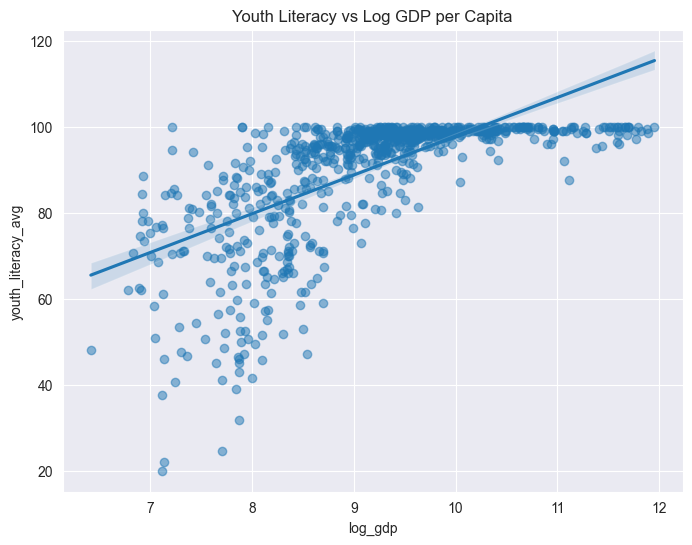

In [11]:
# Youth Literacy Visualization
plt.figure(figsize = (8, 6))
sns.regplot(x = "log_gdp", y = "youth_literacy_avg", data = df5, scatter_kws = {'alpha' : 0.5})
plt.title("Youth Literacy vs Log GDP per Capita")
plt.show()

### Youth literacy demonstrates a strong positive association with GDP per capita and exhibits faster convergence toward universal levels compared to adult literacy. This suggests that economic development translates more immediately into improved educational access for younger populations, while adult literacy reflects historical educational conditions.

In [12]:
# Since log_gdp is normal, but literacy_index is non-normal, we use spearman corr
# Subset and drop missing values
subset = df5[['literacy_index', 'log_gdp']].dropna()

# Spearman correlation
corr_coef, p_value = spearmanr(subset['literacy_index'], subset['log_gdp'])
print("Spearman correlation coefficient:", corr_coef)
print("p-value:", p_value)

Spearman correlation coefficient: 0.7466063124980903
p-value: 6.195168330459161e-158


Interpretation:

corr_coef ≈ 0.65–0.7 (example) → strong monotonic relationship

Literacy tends to increase with GDP, even if the relationship isn’t strictly linear

p-value < 0.05 → correlation is statistically significant

## Literacy vs Education Expenditure

In [13]:
# Starting with the Correlation
df5[["literacy_index", "education_development_index", "education_spend_efficiency", "avg_schooling_years", "log_gdp"]].corr()

,literacy_index,education_development_index,education_spend_efficiency,avg_schooling_years,log_gdp
literacy_index,1.000000,0.982349,0.380337,0.813083,0.701667
education_development_index,0.982349,1.000000,0.353706,0.907625,0.738361
education_spend_efficiency,0.380337,0.353706,1.000000,0.247202,-0.369647
avg_schooling_years,0.813083,0.907625,0.247202,1.000000,0.723384
log_gdp,0.701667,0.738361,-0.369647,0.723384,1.000000


### The Education Development Index almost fully explains literacy outcomes.(LI vs EDI)

### More years of schooling strongly correspond to higher literacy levels.(LI vs ASY)

### Economic development strongly supports literacy outcomes.(LI vs LG)

### Spending efficiency alone does not strongly determine literacy outcomes.(LI vs ESE)

### As GDP increases, measured spending efficiency decreases.(ESE vs GDP)

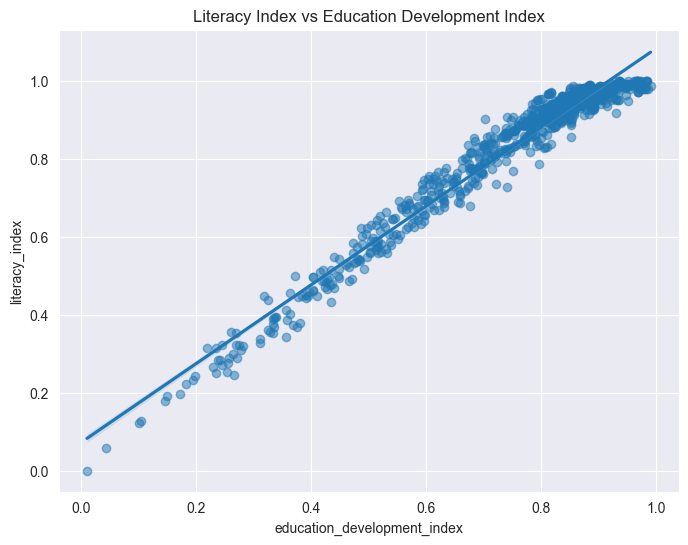

In [14]:
# Scatter Plot between Literacy and Education Index
plt.figure(figsize = (8, 6))
sns.regplot(x = "education_development_index", y = "literacy_index", data = df5, scatter_kws = {"alpha" : 0.5})
plt.title("Literacy Index vs Education Development Index")
plt.show()

### Structural education development explains literacy better than GDP alone.

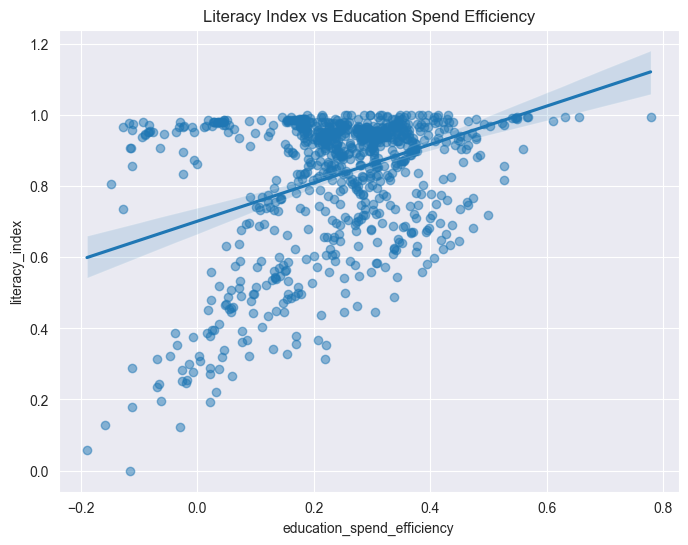

In [15]:
# Structure Plot Between Literacy Index and Education Spend Efficiency
plt.figure(figsize = (8, 6))
sns.regplot(x = "education_spend_efficiency", y = "literacy_index", data = df5, scatter_kws = {"alpha" : 0.5})
plt.title("Literacy Index vs Education Spend Efficiency")
plt.show()

### Although education spending efficiency exhibits a positive relationship with literacy outcomes, the association is moderate (r = 0.38) and characterized by substantial dispersion. This suggests that while efficient allocation of resources contributes to literacy performance, structural education factors such as schooling duration and long-term policy investment play a more dominant role. Additionally, a ceiling effect is evident at high literacy levels, indicating diminishing marginal returns to efficiency improvements.

In [16]:
# Overperformers & Underperformers
df5[(df5['education_spend_efficiency'] > df5['education_spend_efficiency'].quantile(0.75)) &
    (df5['literacy_index'] < df5['literacy_index'].quantile(0.25))]

,country,code,year,adult_literacy_rate,youth_literacy_rate_M,youth_literacy_rate_F,continent,invalid_literacy_flag,adult_literacy_rate_outlier_flag,youth_literacy_rate_M_outlier_flag,...,regional_convergence_index,avg_schooling_years,adult_literacy_rate_norm,youth_literacy_avg_norm,avg_schooling_years_norm,literacy_index,education_development_index,log_gdp,log_gdp_norm,education_spend_efficiency
111,Burundi,BDI,2000,59.000000,77.00000,70.00000,Africa,False,False,False,...,NaN,4.300,0.523256,0.668750,0.271215,0.581453,0.488382,6.940679,0.094528,0.393853
112,Burundi,BDI,2005,53.500000,72.00000,52.83000,Africa,False,False,True,...,2.853020,4.300,0.459302,0.530188,0.271215,0.487656,0.422724,6.889116,0.085215,0.337509
114,Burundi,BDI,2010,55.000000,82.66000,66.51000,Africa,False,False,False,...,-10.442340,4.300,0.476744,0.682313,0.271215,0.558972,0.472644,6.898754,0.086956,0.385689
115,Burundi,BDI,2014,62.000000,85.00000,75.00000,Africa,False,False,False,...,-2.463073,4.300,0.558140,0.750000,0.271215,0.634884,0.525783,6.929802,0.092564,0.433219
116,Burundi,BDI,2016,65.687740,86.75510,82.08605,Africa,False,False,False,...,-4.282289,4.450,0.601020,0.805257,0.283694,0.682715,0.563009,6.917345,0.090314,0.472695
117,Burundi,BDI,2017,68.000000,91.00000,86.00000,Africa,False,False,False,...,8.149330,4.600,0.627907,0.856250,0.296173,0.719244,0.592323,6.931443,0.092860,0.499463
118,Cambodia,KHM,1998,67.000000,82.00000,71.00000,Asia,False,False,False,...,-13.788582,3.548,0.616279,0.706250,0.208652,0.652267,0.519183,7.379248,0.173745,0.345438
120,Cambodia,KHM,2004,74.000000,88.00000,79.00000,Asia,False,False,False,...,7.313490,4.136,0.697674,0.793750,0.257571,0.736105,0.592544,7.820564,0.253458,0.339087
121,Cambodia,KHM,2005,75.500000,100.00000,67.33000,Asia,False,False,False,...,-6.563779,4.260,0.715116,0.795813,0.267887,0.747395,0.603542,7.930886,0.273385,0.330158
199,Democratic Republic of Congo,COD,2001,67.000000,78.00000,63.00000,Africa,False,False,False,...,-11.888175,3.534,0.616279,0.631250,0.207488,0.622267,0.497833,6.836107,0.075640,0.422193


In [17]:
# Since education_spend_efficiency is often non-normal and we already know literacy_index is non-normal, we again use Spearman Rank Correlation to measure monotonic relationships.

# Subset and drop missing values
subset = df5[['literacy_index', 'education_spend_efficiency']].dropna()

# Spearman correlation
corr_coef, p_value = spearmanr(subset['literacy_index'], subset['education_spend_efficiency'])
print("Spearman correlation coefficient:", corr_coef)
print("p-value:", p_value)

Spearman correlation coefficient: 0.19248509799542385
p-value: 8.29373745594372e-09


corr_coef ≈ 0 → weak or no monotonic relationship

p-value < 0.05 → statistically significant relationship

## Enrollment vs Literacy Growth

In [18]:
# Enrollment proxies access to education
df5[["avg_schooling_years", "literacy_momentum_5yr"]].corr()

,avg_schooling_years,literacy_momentum_5yr
avg_schooling_years,1.000000,-0.553168
literacy_momentum_5yr,-0.553168,1.000000


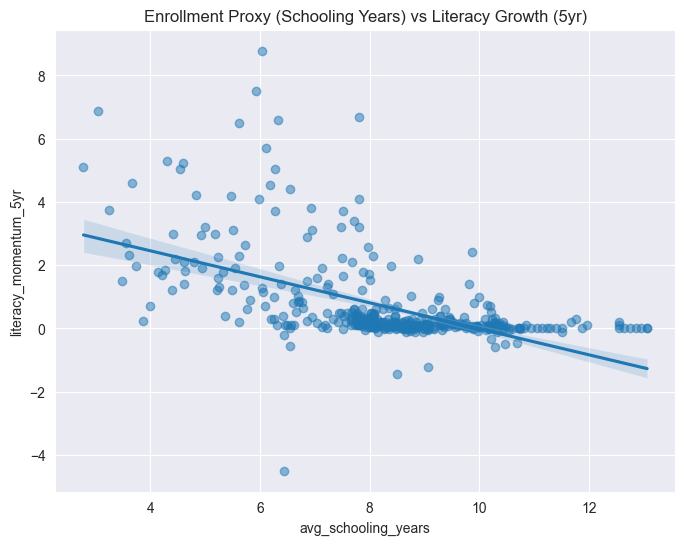

In [19]:
# Scatter Plot
plt.figure(figsize = (8, 6))
sns.regplot(x = "avg_schooling_years", y = "literacy_momentum_5yr", data = df5, scatter_kws = {"alpha" : 0.5})
plt.title("Enrollment Proxy (Schooling Years) vs Literacy Growth (5yr)")
plt.show()

### A negative association is observed between average schooling years and 5-year literacy momentum, reflecting a saturation effect rather than a causal decline. Countries with higher schooling levels tend to exhibit slower literacy growth because they have already achieved near-universal literacy. In contrast, middle-income countries with expanding educational access experience the highest literacy acceleration.

In [20]:
# Compute Spearman Correlation: Avg Schooling vs 5-Year Moment
# Subset relevant columns and drop missing values
subset = df5[['avg_schooling_years', 'literacy_momentum_5yr']].dropna()

# Spearman correlation
corr_coef, p_value = spearmanr(subset['avg_schooling_years'], subset['literacy_momentum_5yr'])
print("Spearman correlation coefficient:", corr_coef)
print("p-value:", p_value)

Spearman correlation coefficient: -0.6265012142882402
p-value: 9.731435307101497e-47


Interpretation

Negative correlation:
Surprisingly, higher average schooling years is associated with lower 5-Year Literacy Momentum.

This indicates a convergence effect:
Countries with already high schooling & literacy levels see slower growth, because most of the population is already literate.
Countries with lower schooling tend to experience faster literacy gains (catch-up effect).

Statistical significance:
Extremely low p-value confirms this is not due to chance.

Policy insight:
Investment in schooling alone may not accelerate literacy in already developed countries.
Catch-up growth occurs primarily in countries with low starting literacy & schooling.
Supports targeted interventions rather than uniform policy.

## Gender Gap vs Continent

In [21]:
# Drop missing values
anova_df = df5[['continent', 'literacy_gender_gap_abs']].dropna()

# Check group sizes
anova_df['continent'].value_counts()

continent
Asia             275
Africa           228
South America    187
North America    131
Europe            68
Oceania            7
Name: count, dtype: int64

In [22]:
# Create list of arrays by continent
groups = [
    anova_df[anova_df['continent'] == c]['literacy_gender_gap_abs']
    for c in anova_df['continent'].unique()
]

stat, p_value = f_oneway(*groups)

print("ANOVA F-statistic:", stat)
print("p-value:", p_value)

ANOVA F-statistic: 42.824021940864846
p-value: 1.3321101216451001e-39


Gender disparity in literacy is strongly structured by region.

There are statistically significant differences in literacy gender gap across continents.

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=anova_df['literacy_gender_gap_abs'],
    groups=anova_df['continent'],
    alpha=0.05
)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------
       Africa          Asia  -5.0294    0.0  -6.9096 -3.1493   True
       Africa        Europe  -8.5743    0.0 -11.4748 -5.6739   True
       Africa North America  -9.4534    0.0 -11.7548  -7.152   True
       Africa       Oceania  -6.6662 0.1704 -14.7211  1.3888  False
       Africa South America  -8.6984    0.0 -10.7694 -6.6274   True
         Asia        Europe  -3.5449 0.0052  -6.3879 -0.7019   True
         Asia North America   -4.424    0.0  -6.6524 -2.1955   True
         Asia       Oceania  -1.6367 0.9922  -9.6711  6.3977  False
         Asia South America   -3.669    0.0  -5.6586 -1.6793   True
       Europe North America  -0.8791 0.9675  -4.0165  2.2584  False
       Europe       Oceania   1.9082 0.9867  -6.4242 10.2406  False
       Europe South America  -0.1241    1.0  -3.

### Africa has significantly higher literacy gender gaps than Asia, Europe, North America, and South America.

### Asia has significantly higher gender gaps than Europe, North America, and South America.

### Europe, North America, South America - these three regions are statistically similar in gender parity — and likely low gap regions.

## Categorical Literacy Growth

In [24]:
# Compute total literacy change per country
country_growth = df5.groupby('country')['literacy_index'].agg(
    total_change=lambda x: x.max() - x.min()
).reset_index()

# Merge continent
country_growth = country_growth.merge(
    df5[['country','continent']].drop_duplicates(),
    on='country',
    how='left'
)

# Create High/Low category using median
median_growth = country_growth['total_change'].median()

country_growth['growth_category'] = country_growth['total_change'].apply(
    lambda x: 'High' if x >= median_growth else 'Low'
)

In [25]:
# Create Contingency Table
contingency_table = pd.crosstab(
    country_growth['continent'],
    country_growth['growth_category']
)

contingency_table

growth_category,High,Low
continent,,
Africa,30,5
Asia,19,17
Europe,0,18
North America,6,7
Oceania,1,1
South America,2,9


In [26]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 40.49408878242817
p-value: 1.1870999700627426e-07
Degrees of freedom: 5


### There is a statistically significant association between literacy growth category (High vs Low) and continent.

### Literacy improvement is not randomly distributed across regions.

## Correlation Heatmap

In [27]:
# Selecting Variables
cols = [
    'adult_literacy_rate',
    'youth_literacy_avg',
    'literacy_gender_gap_abs',
    'avg_schooling_years',
    'literacy_index',
    'education_development_index',
    'education_spend_efficiency',
    'log_gdp',
    'gender_gap_pct',
    'regional_convergence_index',
    'literacy_momentum_5yr',
    'literacy_stability_index'
]

corr_matrix = df5[cols].corr()

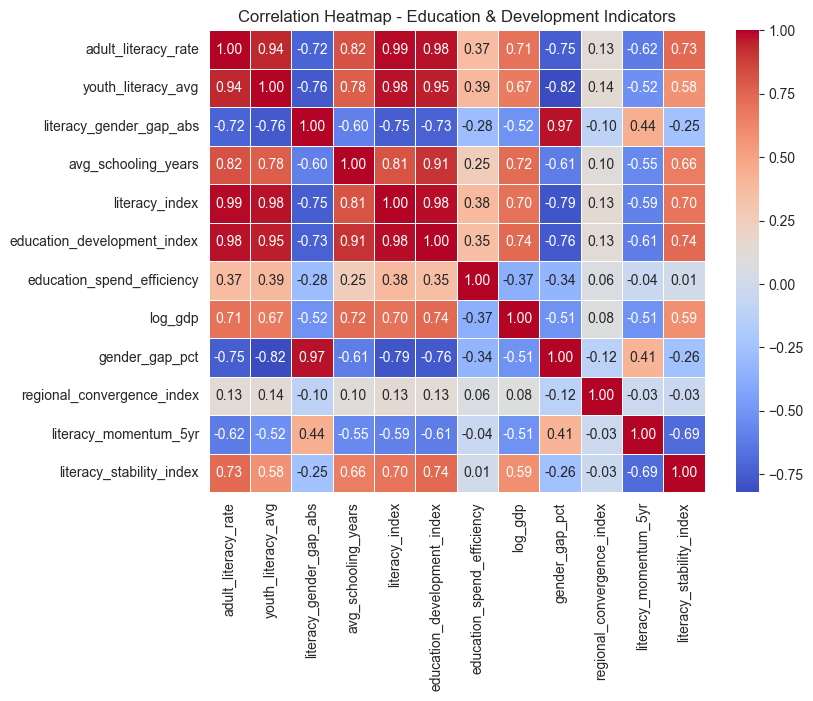

In [28]:
plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidth = 0.5)
plt.title("Correlation Heatmap - Education & Development Indicators")
plt.show()

### Strong Positive Correlations -
Countries with higher adult literacy almost always have higher youth literacy. Strong intergenerational literacy correlation.

The literacy index is largely driven by adult literacy—makes sense because adult literacy is a core component.

Higher literacy strongly aligns with broader education and development metrics. Countries with educated adults tend to score higher on overall educational development.

Longer average schooling strongly indicates better overall educational development.

Wealthier countries (higher GDP) tend to have higher literacy rates, but correlation is moderate—economic growth supports education but isn’t the sole factor.

### Strong Negative Correlations -
Higher youth literacy is associated with smaller gender gaps. Improving literacy tends to close gender disparities.

Countries with higher adult literacy generally have smaller gender gaps in literacy.

Different metrics measuring gender disparities are almost perfectly aligned—consistent with expectations.

Slight negative relationship: wealthier countries may have smaller recent changes in literacy because they already have high literacy rates (momentum slows as it approaches saturation).